# Credit Card Transaction Anomaly Detection using Isolation Forest

**Project Type:** Unsupervised Machine Learning  
**Algorithm:** Isolation Forest  
**Business Use Case:** Detect unusual / potentially fraudulent credit-card transactions.

This notebook covers data loading, EDA, feature engineering, Isolation Forest training, anomaly scoring, evaluation, visualization, model persistence, and prediction on a new transaction.


In [1]:
# Install packages if needed:
# !pip install pandas numpy matplotlib seaborn scikit-learn joblib

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


## 1. Load Dataset

In [2]:
df = pd.read_csv(r"C:\Users\Adarsh\Downloads\Credit-Card-Anomaly-Detection-Isolation-Forest\credit_card_transactions.csv", parse_dates=["transaction_datetime"])
print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (10000, 12)


,transaction_id,transaction_amount,transaction_hour,distance_from_home_km,merchant_risk_score,transactions_last_24h,device_change_count,account_age_days,failed_attempts,international_transaction,actual_anomaly,transaction_datetime
0,TXN006253,183.942487,9,10.881114,0.294335,3,0,2003,0,0,0,2026-02-05 09:52:00
1,TXN004685,16.876246,22,6.797886,0.382711,4,0,1487,0,0,0,2026-02-13 22:30:00
2,TXN001732,26.388916,11,4.676423,0.492950,4,1,1612,0,0,0,2026-02-05 11:28:00
3,TXN004743,33.150320,9,19.220548,0.258347,2,0,764,0,0,0,2026-02-16 09:35:00
4,TXN004522,66.574156,9,16.656727,0.201170,3,0,771,0,0,0,2026-01-15 09:32:00


## 2. Data Quality Checks

In [3]:
print("Data types:")
display(df.dtypes.to_frame("dtype"))

print("Missing values:")
display(df.isnull().sum().to_frame("missing"))

print("Duplicate rows:", df.duplicated().sum())

display(df.describe().T)


Data types:


,dtype
transaction_id,object
transaction_amount,float64
transaction_hour,int64
distance_from_home_km,float64
merchant_risk_score,float64
transactions_last_24h,int64
device_change_count,int64
account_age_days,int64
failed_attempts,int64
international_transaction,int64


Missing values:


,missing
transaction_id,0
transaction_amount,0
transaction_hour,0
distance_from_home_km,0
merchant_risk_score,0
transactions_last_24h,0
device_change_count,0
account_age_days,0
failed_attempts,0
international_transaction,0


Duplicate rows: 0


,count,mean,min,25%,50%,75%,max,std
transaction_amount,10000.0,68.660552,2.735116,21.973662,34.472367,55.752487,4863.75427,168.557169
transaction_hour,10000.0,13.983,0.0,10.0,14.0,18.0,23.0,5.202328
distance_from_home_km,10000.0,14.632146,0.022093,3.996543,7.109095,11.738661,552.356222,32.813026
merchant_risk_score,10000.0,0.325716,0.0,0.221176,0.30628,0.395997,1.0,0.164063
transactions_last_24h,10000.0,4.6629,1.0,3.0,4.0,5.0,28.0,3.428591
device_change_count,10000.0,0.5725,0.0,0.0,0.0,1.0,10.0,1.078545
account_age_days,10000.0,1217.7698,2.0,545.0,1206.0,1859.0,2499.0,732.675192
failed_attempts,10000.0,0.4917,0.0,0.0,0.0,1.0,10.0,1.034716
international_transaction,10000.0,0.1047,0.0,0.0,0.0,0.0,1.0,0.306182
actual_anomaly,10000.0,0.05,0.0,0.0,0.0,0.0,1.0,0.217956


## 3. Exploratory Data Analysis

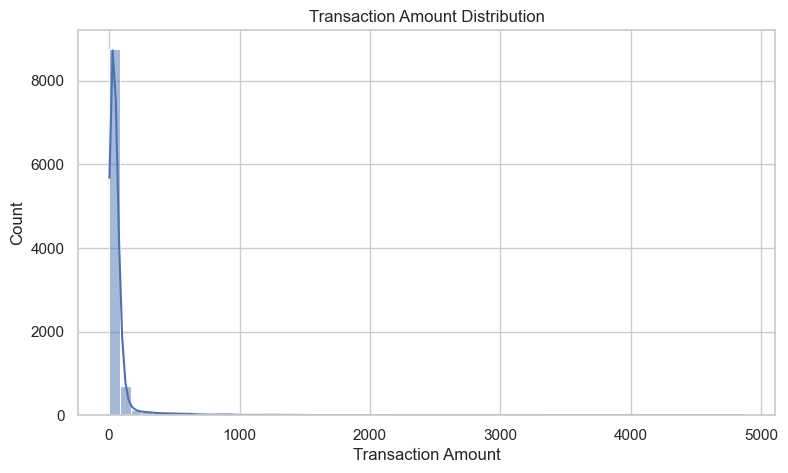

In [4]:
plt.figure(figsize=(9,5))
sns.histplot(df["transaction_amount"], bins=60, kde=True)
plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.show()


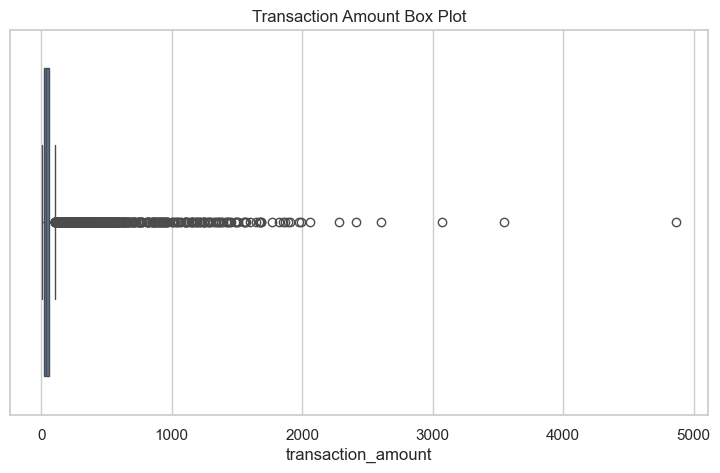

In [5]:
plt.figure(figsize=(9,5))
sns.boxplot(x=df["transaction_amount"])
plt.title("Transaction Amount Box Plot")
plt.show()


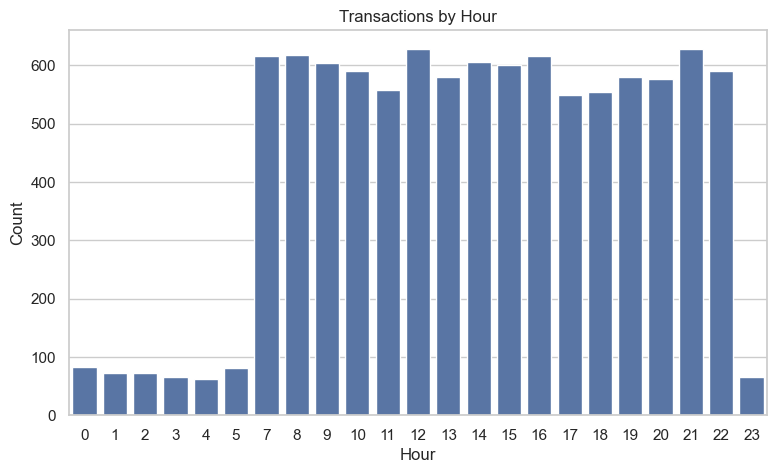

In [6]:
plt.figure(figsize=(9,5))
sns.countplot(data=df, x="transaction_hour")
plt.title("Transactions by Hour")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.show()


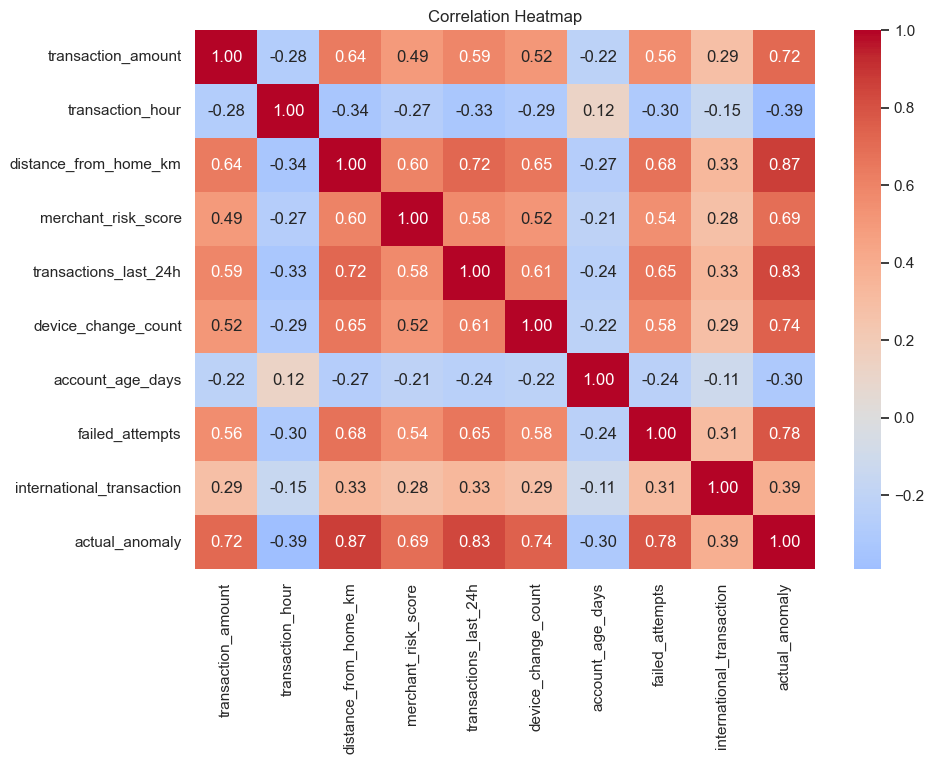

In [7]:
plt.figure(figsize=(10,7))
sns.heatmap(df.select_dtypes("number").corr(), annot=True, fmt=".2f",
            cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()


## 4. Feature Engineering

In [8]:
df["amount_log"] = np.log1p(df["transaction_amount"])
df["is_night"] = ((df["transaction_hour"] < 6) | (df["transaction_hour"] >= 23)).astype(int)
df["high_velocity"] = (df["transactions_last_24h"] >= 8).astype(int)
df["high_distance"] = (df["distance_from_home_km"] >= 50).astype(int)

features = [
    "amount_log", "transaction_hour", "distance_from_home_km",
    "merchant_risk_score", "transactions_last_24h", "device_change_count",
    "account_age_days", "failed_attempts", "international_transaction",
    "is_night", "high_velocity", "high_distance"
]

X = df[features]
print("Feature matrix shape:", X.shape)
print("Features:", features)


Feature matrix shape: (10000, 12)
Features: ['amount_log', 'transaction_hour', 'distance_from_home_km', 'merchant_risk_score', 'transactions_last_24h', 'device_change_count', 'account_age_days', 'failed_attempts', 'international_transaction', 'is_night', 'high_velocity', 'high_distance']


## 5. Feature Scaling

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Scaling completed.")


Scaling completed.


## 6. Train Isolation Forest

In [10]:
model = IsolationForest(
    n_estimators=300,
    contamination=0.05,
    max_samples="auto",
    max_features=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

model.fit(X_scaled)

df["model_prediction"] = model.predict(X_scaled)
df["predicted_anomaly"] = (df["model_prediction"] == -1).astype(int)
df["anomaly_score"] = -model.decision_function(X_scaled)

print("Predicted classes:")
print(df["predicted_anomaly"].value_counts())


Predicted classes:
predicted_anomaly
0    9500
1     500
Name: count, dtype: int64


## 7. Detected Anomalies

In [11]:
anomalies = df[df["predicted_anomaly"] == 1].copy()

print("Total transactions:", len(df))
print("Detected anomalies:", len(anomalies))
print("Anomaly rate:", round(len(anomalies) / len(df) * 100, 2), "%")

display(anomalies.sort_values("anomaly_score", ascending=False)[[
    "transaction_id", "transaction_datetime", "transaction_amount",
    "distance_from_home_km", "merchant_risk_score",
    "transactions_last_24h", "failed_attempts",
    "international_transaction", "anomaly_score"
]].head(20))


Total transactions: 10000
Detected anomalies: 500
Anomaly rate: 5.0 %


,transaction_id,transaction_datetime,transaction_amount,distance_from_home_km,merchant_risk_score,transactions_last_24h,failed_attempts,international_transaction,anomaly_score
4091,TXN009573,2026-01-26 02:24:00,110.809199,300.896644,0.951760,24,4,0,0.097097
2755,TXN009557,2026-01-04 23:03:00,1508.842731,73.381681,0.961687,17,5,1,0.090880
1569,TXN009511,2026-01-11 23:27:00,1352.698949,109.859805,0.946990,16,8,1,0.087965
4165,TXN009870,2026-03-25 00:11:00,1642.148337,43.090314,0.876516,13,6,0,0.087873
2753,TXN009583,2026-02-09 03:14:00,615.649166,170.798112,0.951915,13,7,0,0.086234
560,TXN009973,2026-01-20 23:53:00,1286.231334,38.576509,0.686504,19,2,1,0.086061
2237,TXN009873,2026-01-17 23:11:00,1485.710407,300.816036,0.689795,19,4,1,0.084576
8185,TXN009603,2026-01-07 23:41:00,1231.263934,154.191926,0.897699,22,5,1,0.084349
4976,TXN009944,2026-03-18 23:48:00,571.874643,220.133744,0.840213,23,6,1,0.084008
4861,TXN009888,2026-03-18 23:00:00,297.286456,204.108117,0.918491,19,7,1,0.083808


## 8. Anomaly Visualization

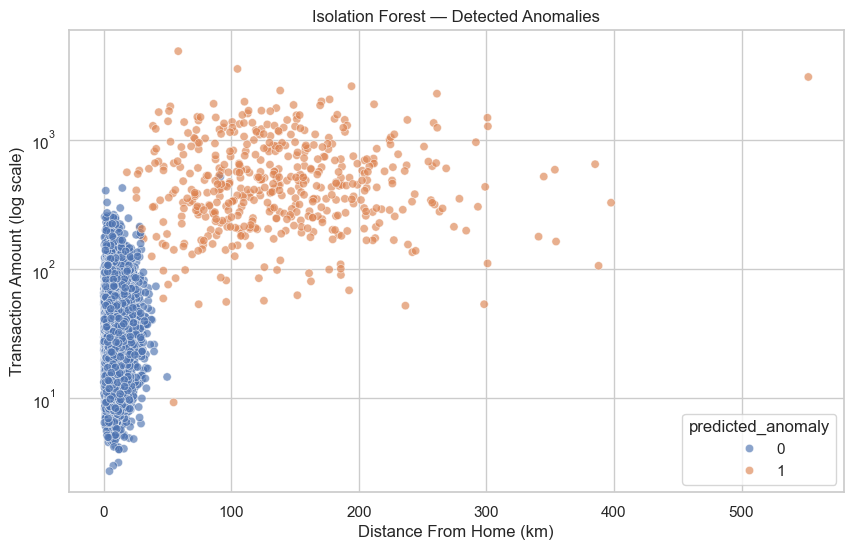

In [12]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x="distance_from_home_km",
    y="transaction_amount",
    hue="predicted_anomaly",
    alpha=.65
)
plt.yscale("log")
plt.title("Isolation Forest — Detected Anomalies")
plt.xlabel("Distance From Home (km)")
plt.ylabel("Transaction Amount (log scale)")
plt.show()


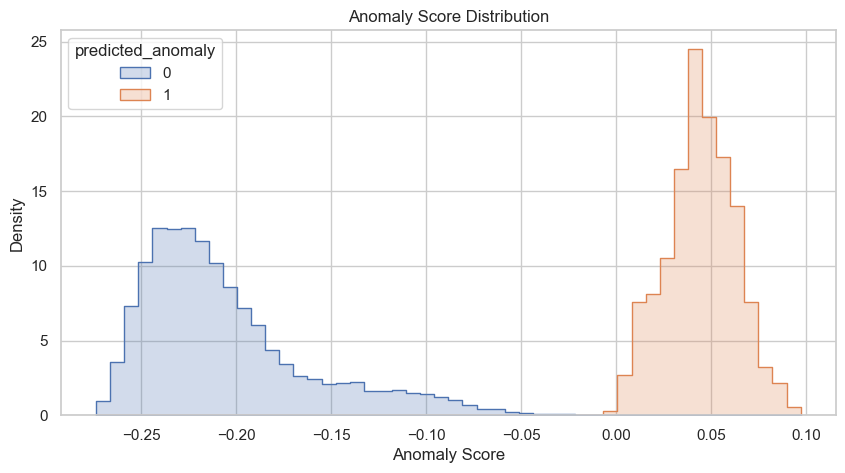

In [13]:
plt.figure(figsize=(10,5))
sns.histplot(
    data=df, x="anomaly_score", hue="predicted_anomaly",
    bins=50, element="step", stat="density", common_norm=False
)
plt.title("Anomaly Score Distribution")
plt.xlabel("Anomaly Score")
plt.show()


## 9. Optional Model Evaluation

In [14]:
# actual_anomaly is available because this is a synthetic dataset.
# For a real unsupervised dataset, true labels may not exist.

y_true = df["actual_anomaly"]
y_pred = df["predicted_anomaly"]

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=4))

print("ROC-AUC:", round(roc_auc_score(y_true, df["anomaly_score"]), 4))


Confusion Matrix:
[[9499    1]
 [   1  499]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9999    0.9999    0.9999      9500
           1     0.9980    0.9980    0.9980       500

    accuracy                         0.9998     10000
   macro avg     0.9989    0.9989    0.9989     10000
weighted avg     0.9998    0.9998    0.9998     10000

ROC-AUC: 1.0


## 10. Highest-Risk Transactions

In [15]:
risk = df.sort_values("anomaly_score", ascending=False).head(25)

display(risk[[
    "transaction_id", "transaction_datetime", "transaction_amount",
    "distance_from_home_km", "merchant_risk_score",
    "transactions_last_24h", "device_change_count",
    "failed_attempts", "international_transaction",
    "anomaly_score", "predicted_anomaly"
]])


,transaction_id,transaction_datetime,transaction_amount,distance_from_home_km,merchant_risk_score,transactions_last_24h,device_change_count,failed_attempts,international_transaction,anomaly_score,predicted_anomaly
4091,TXN009573,2026-01-26 02:24:00,110.809199,300.896644,0.951760,24,8,4,0,0.097097,1
2755,TXN009557,2026-01-04 23:03:00,1508.842731,73.381681,0.961687,17,6,5,1,0.090880,1
1569,TXN009511,2026-01-11 23:27:00,1352.698949,109.859805,0.946990,16,5,8,1,0.087965,1
4165,TXN009870,2026-03-25 00:11:00,1642.148337,43.090314,0.876516,13,6,6,0,0.087873,1
2753,TXN009583,2026-02-09 03:14:00,615.649166,170.798112,0.951915,13,8,7,0,0.086234,1
560,TXN009973,2026-01-20 23:53:00,1286.231334,38.576509,0.686504,19,7,2,1,0.086061,1
2237,TXN009873,2026-01-17 23:11:00,1485.710407,300.816036,0.689795,19,3,4,1,0.084576,1
8185,TXN009603,2026-01-07 23:41:00,1231.263934,154.191926,0.897699,22,6,5,1,0.084349,1
4976,TXN009944,2026-03-18 23:48:00,571.874643,220.133744,0.840213,23,2,6,1,0.084008,1
4861,TXN009888,2026-03-18 23:00:00,297.286456,204.108117,0.918491,19,5,7,1,0.083808,1


## 11. Save Results and Model

In [16]:
df.to_csv("isolation_forest_transaction_results.csv", index=False)
joblib.dump(model, "isolation_forest_model.joblib")
joblib.dump(scaler, "transaction_feature_scaler.joblib")

print("Saved:")
print("- isolation_forest_transaction_results.csv")
print("- isolation_forest_model.joblib")
print("- transaction_feature_scaler.joblib")


Saved:
- isolation_forest_transaction_results.csv
- isolation_forest_model.joblib
- transaction_feature_scaler.joblib


## 12. Test a New Transaction

In [17]:
new_transaction = pd.DataFrame([{
    "transaction_amount": 8500,
    "transaction_hour": 2,
    "distance_from_home_km": 180,
    "merchant_risk_score": 0.92,
    "transactions_last_24h": 15,
    "device_change_count": 4,
    "account_age_days": 60,
    "failed_attempts": 4,
    "international_transaction": 1
}])

new_transaction["amount_log"] = np.log1p(new_transaction["transaction_amount"])
new_transaction["is_night"] = (
    (new_transaction["transaction_hour"] < 6) |
    (new_transaction["transaction_hour"] >= 23)
).astype(int)
new_transaction["high_velocity"] = (new_transaction["transactions_last_24h"] >= 8).astype(int)
new_transaction["high_distance"] = (new_transaction["distance_from_home_km"] >= 50).astype(int)

new_scaled = scaler.transform(new_transaction[features])
prediction = model.predict(new_scaled)[0]
score = -model.decision_function(new_scaled)[0]

print("Prediction:", "ANOMALY / HIGH RISK" if prediction == -1 else "NORMAL")
print("Anomaly score:", round(float(score), 4))


Prediction: ANOMALY / HIGH RISK
Anomaly score: 0.0321


## 13. Business Recommendations

1. Send high-risk transactions to a fraud-review queue.
2. Apply additional authentication to very high-risk transactions.
3. Investigate unusual amount, distance, device, velocity, and failed-attempt patterns.
4. Tune `contamination` using historical validation data.
5. Retrain periodically as fraud behavior changes.
6. Monitor false positives and model drift.
7. In production, combine Isolation Forest with business rules and supervised fraud models when labels are available.

## 14. Project Summary

**Input:** Transaction behavior features  
**Model:** Isolation Forest  
**Output:** Normal / Anomaly and anomaly score


